In [ ]:
!pip install -q "numpy<2.0" gdown albumentations

In [ ]:
import os
import shutil
import gdown
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

print(f"TensorFlow version: {tf.__version__}")
print(f"Numpy version: {np.__version__}")

gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    print("WARNING: No GPU found. Check 'Session Options' -> Accelerator.")
else:
    print(f"SUCCESS: Found {len(gpus)} GPU(s).")

TensorFlow version: 2.18.0
Numpy version: 1.26.4
SUCCESS: Found 2 GPU(s).


In [ ]:
WORKING_DIR = '/kaggle/working'
EXTRACTED_DIR = os.path.join(WORKING_DIR, 'AI_Tourist_Dataset')
ZIP_NAME = 'AI_Tourist_Dataset_10Classes.zip'
ZIP_PATH = os.path.join(WORKING_DIR, ZIP_NAME)

file_id = '1tp-EaiiatkWasCjAlMYCMdHx29eyNBEr'
url = f'https://drive.google.com/uc?id={file_id}'

if not os.path.exists(ZIP_PATH):
    print(f"Downloading {ZIP_NAME} from Google Drive...")
    gdown.download(url, ZIP_PATH, quiet=False, fuzzy=True)
else:
    print("Zip file already exists. Skipping download.")

Zip file already exists. Skipping download.


In [ ]:
if os.path.exists(EXTRACTED_DIR):
    shutil.rmtree(EXTRACTED_DIR)

print("Extracting dataset...")
!unzip -q {ZIP_PATH} -d {EXTRACTED_DIR}

nested_folder = os.path.join(EXTRACTED_DIR, 'AI_Tourist_Dataset_10Classes')
macosx_folder = os.path.join(EXTRACTED_DIR, '__MACOSX')

if os.path.exists(macosx_folder):
    shutil.rmtree(macosx_folder)

if os.path.exists(nested_folder):
    print(f"Moving files out of nested folder: {os.path.basename(nested_folder)}...")
    for item in os.listdir(nested_folder):
        src_path = os.path.join(nested_folder, item)
        dst_path = os.path.join(EXTRACTED_DIR, item)
        shutil.move(src_path, dst_path)
    os.rmdir(nested_folder)

print("-" * 30)
print(f"Data located in: {EXTRACTED_DIR}")
for root, dirs, files in os.walk(EXTRACTED_DIR):
    depth = root[len(EXTRACTED_DIR):].count(os.sep)
    if depth == 1:
        print(f"  Folder: {os.path.basename(root)} | Files: {len(files)}")

Extracting dataset...
Moving files out of nested folder: AI_Tourist_Dataset_10Classes...
------------------------------
Data located in: /kaggle/working/AI_Tourist_Dataset
  Folder: train | Files: 1
  Folder: test | Files: 1
  Folder: valid | Files: 1


In [ ]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
BASE_DIR = EXTRACTED_DIR

train_dir = os.path.join(BASE_DIR, "train")
val_dir = os.path.join(BASE_DIR, "valid")
test_dir = os.path.join(BASE_DIR, "test")

train_ds = image_dataset_from_directory(train_dir, label_mode='categorical', batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE, shuffle=True, seed=42)

val_ds = image_dataset_from_directory(val_dir, label_mode='categorical',
    batch_size=BATCH_SIZE, image_size=IMAGE_SIZE)

test_ds = image_dataset_from_directory(test_dir, label_mode='categorical',
    batch_size=BATCH_SIZE, image_size=IMAGE_SIZE)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.08),
])

def prepare(ds, augment=False):
    def _map(img, label):
        img = tf.cast(img, tf.float32)
        if augment:
            img = data_augmentation(img)
        return img, label
    return ds.map(_map, num_parallel_calls=AUTOTUNE)

train_ds_prep = prepare(train_ds, True)
val_ds_prep = prepare(val_ds, False)

Found 71022 files belonging to 10 classes.
Found 20 files belonging to 10 classes.
Found 30 files belonging to 10 classes.
Classes: ['AmenhotebIII and wife Tiye', 'Bent pyramid for senefru', 'Colossoi of Memnon', 'Hatshepsut', 'Khafre Pyramid', 'Ramesses II', 'Temple of Ramessum', 'The Great Temple of Ramesses II', 'Tut Ankh Amun', 'sphinx']


In [ ]:
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224,224,3))
base_model.trainable = True
for layer in base_model.layers[:200]:
    layer.trainable = False

inputs = layers.Input(shape=(224,224,3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model_Efficient = Model(inputs, outputs)

callbacks = [EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

model_Efficient.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
model_Efficient.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 2,063,514 (7.87 MB)

 Non-trainable params: 1,998,867 (7.63 MB)

In [ ]:
history_Efficient = model_Efficient.fit(train_ds_prep, validation_data=val_ds_prep, epochs=100, callbacks=callbacks)

Epoch 1/100
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 355s 160ms/step - accuracy: 0.8766 - loss: 0.5939 - val_accuracy: 0.9500 - val_loss: 0.0919
Epoch 2/100
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 339s 152ms/step - accuracy: 0.9445 - loss: 0.1984 - val_accuracy: 1.0000 - val_loss: 0.0400
Epoch 3/100
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 337s 152ms/step - accuracy: 0.9626 - loss: 0.1258 - val_accuracy: 1.0000 - val_loss: 0.0156
Epoch 4/100
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 333s 150ms/step - accuracy: 0.9715 - loss: 0.0943 - val_accuracy: 1.0000 - val_loss: 0.0103
Epoch 5/100
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 339s 152ms/step - accuracy: 0.9780 - loss: 0.0713 - val_accuracy: 1.0000 - val_loss: 0.0056
Epoch 6/100
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 336s 151ms/step - accuracy: 0.9823 - loss: 0.0602 - val_accuracy: 1.0000 - val_loss: 0.0042
Epoch 7/100
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 342s 154ms/step - accuracy: 0.9841 - loss: 0.0502 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 8/100
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 335s 151ms/s

In [ ]:
loss, acc = model_Efficient.evaluate(test_ds)
print(f"Test Accuracy: {acc*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.9667 - loss: 0.4351
Test Accuracy: 96.67%


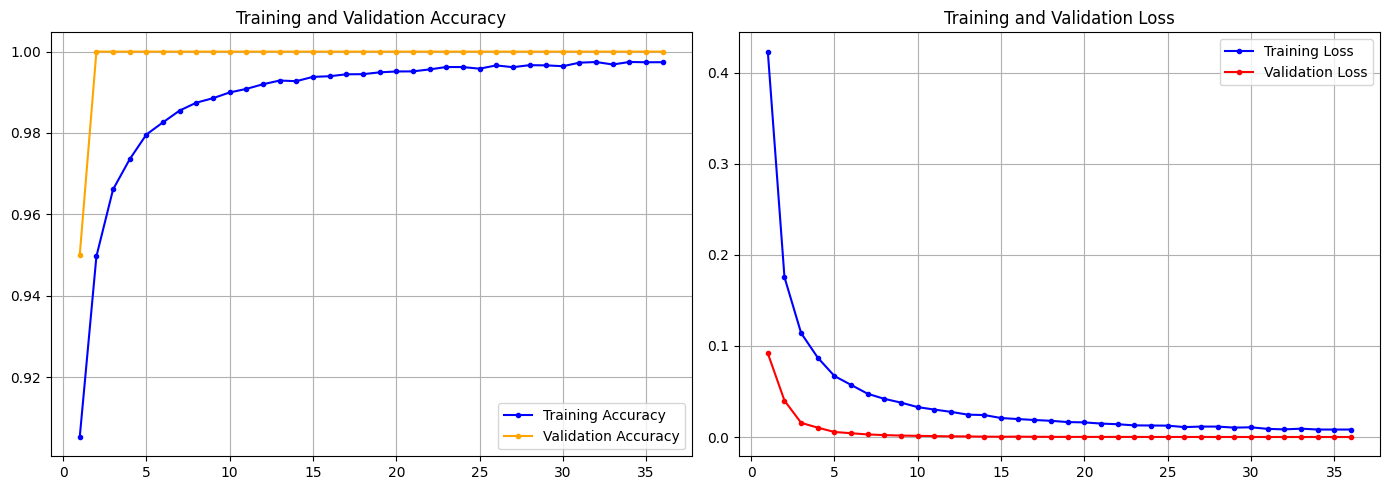

In [ ]:
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy', color='blue', marker='o', markersize=3)
    plt.plot(epochs, val_acc, label='Validation Accuracy', color='orange', marker='o', markersize=3)
    plt.title('Training and Validation Accuracy')
    plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss', color='blue', marker='o', markersize=3)
    plt.plot(epochs, val_loss, label='Validation Loss', color='red', marker='o', markersize=3)
    plt.title('Training and Validation Loss')
    plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_training_history(history_Efficient)

In [ ]:
import os
import shutil

SAVE_DIR = os.path.join(WORKING_DIR, "t5_Deep_Learning")
MODEL_FILENAME = "efficientnet_model.keras"
MODEL_PATH = os.path.join(SAVE_DIR, MODEL_FILENAME)

OUTPUT_ZIP_BASE = os.path.join(WORKING_DIR, 'grad_deep_model')

if os.path.exists(SAVE_DIR):
    shutil.rmtree(SAVE_DIR)


model_Efficient.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

shutil.make_archive(OUTPUT_ZIP_BASE, 'zip', SAVE_DIR)
print(f"SUCCESS! Download 'grad_deep_model.zip' from the Output tab on the right.")

Model saved to: /kaggle/working/t5_Deep_Learning/efficientnet_model.keras
SUCCESS! Download 'grad_deep_model.zip' from the Output tab on the right.


In [ ]:
from IPython.display import FileLink
FileLink(r'grad_deep_model.zip')

/kaggle/working/grad_deep_model.zip